In [1]:
test = '6П14П-ЕР'

In [11]:
# !copy %cd%\..\Ebay\Server\Controllers\Contracts\Ebay.yaml %cd%
# !rmdir %cd%\openapi_client\ /s /q
# !docker run --rm -v %cd%:/local openapitools/openapi-generator-cli:v7.3.0 generate -i /local/Ebay.yaml -g python-pydantic-v1 -o /local/client --additional-properties=generateSourceCodeOnly=true
# !move %cd%/client/openapi_client %cd%/openapi_client
# !rmdir %cd%\client\ /s /q

In [3]:
from openapi_client import CategoryValue, LotInfoShort, ProductWithId, ApiClient, Configuration
from openapi_client.api import DefaultApi
import requests
import pandas as pd
from typing import List
import matplotlib.pyplot as plt
from datetime import datetime
from termcolor import colored
from IPython.display import display
import seaborn as sns

In [4]:
server = "naks42.ru"
port = 17443
clientId = "Ebay.Python"
secret = "ac4ab670-ae20-451a-ab4a-3a20275e807d"

In [5]:
unknown_price_discount = 0.8

In [22]:
def calc_statistics(df):
    mean = df.purchase_total_price_usd.sum() / df.total_pcs_per_purchase.sum()
    print('Среднее: ', mean)
    
    sns.histplot(data=df, x='total_price_per_pcs_usd', weights=df.purchase_quantity, bins=10)
    plt.axvline(x = mean, color = 'b')
    plt.title(product.name + ' Распределение цены для new')
    plt.show()
    
    sns.scatterplot(data=df, x="total_price_per_pcs_usd", y="total_pcs_per_purchase", hue="lot_category_test_state")
    plt.axvline(x = mean, color = 'b')
    plt.show()

################################################## 6П14П-ЕР ##################################################
Продано штук:  124 

Распределение по состоянию (проданных штук): 
new    124 

new
Среднее:  21.80106682696954


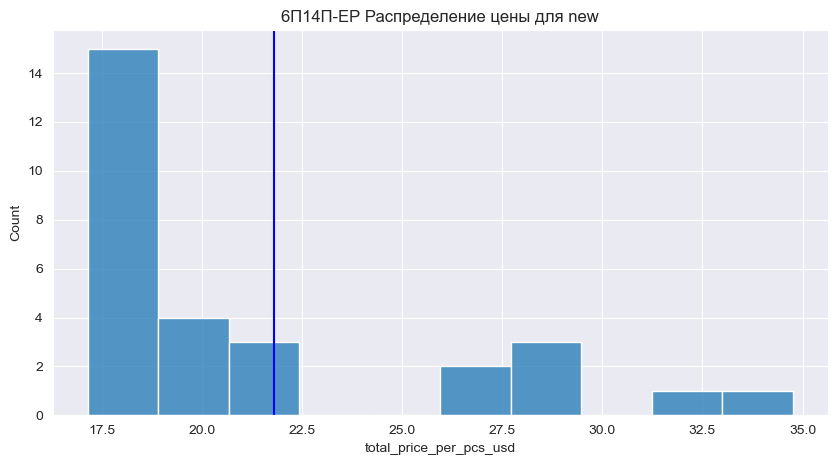

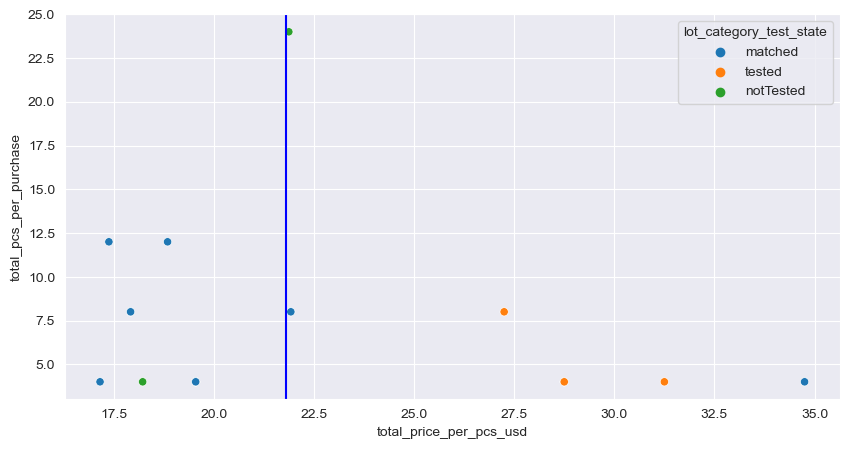

In [24]:
pd.set_option('display.max_columns', None)
#pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
plt.rcParams["figure.figsize"] = (10,5)

def get_access_token(url, client_id, client_secret):
    response = requests.post(
        url,
        data={"grant_type": "client_credentials"},
        auth=(client_id, client_secret),
    )
    return response.json()["access_token"]

token = get_access_token(f"https://{server}:{port}/connect/token", clientId, secret)

client = ApiClient(
    configuration=Configuration(host=f'https://{server}:{port}/api/ebay/v1'), header_name='Authorization',
    header_value='Bearer ' + token)

api = DefaultApi(client)

currencies = api.get_currencies()
currency_rates = {}
for currency in currencies:
    if (datetime.now() - datetime.strptime(currencies[0].last_update, '%Y-%m-%dT%H:%M:%S.%fZ')).days > 1:
        raise Exception("exchange rate isn't accurate " + currency.ebay_name)
    currency_rates[currency.ebay_name] = currency.rate

productRowsExcluded = {'search_queries'}
lotRowsExcluded = {'seller', 'located_in', 'purchase_history', 'categories'}
purchaseExcluded = {}

products: List[ProductWithId] = api.get_all_products()


for product in products:
    if product.name != test: continue
    
    print(colored('#' * 50 + f' {product.name} ' + '#' * 50, "red"))
    
    lots: List[LotInfoShort] = api.get_lots(product_id=product.id)

    productRow = {}
    for key, value in product.__dict__.items():
        if key not in productRowsExcluded:
            productRow[f'product_{key}'] = value

    dataFrameArray = []
    for lot in lots:
        lotRow = productRow.copy()
        for key, value in lot.__dict__.items():
            if key not in lotRowsExcluded:
                lotRow[f'lot_{key}'] = value
        
        for category in lot.categories:
            lotRow[f'lot_category_{category.type}'] = category.value
        
        for purchase in lot.purchase_history:
            purchaseRow = lotRow.copy()
            for key, value in purchase.__dict__.items():
                if key not in purchaseExcluded:
                    purchaseRow[f'purchase_{key}'] = value
            dataFrameArray.append(purchaseRow)
    
    if len(dataFrameArray) == 0:
        print("Нет продаж для лота", '\n')
        continue
    
    df = pd.DataFrame(dataFrameArray)

    df.lot_title_change_date = pd.to_datetime(df.lot_title_change_date)
    df.purchase_var_date = pd.to_datetime(df.purchase_var_date)
    df = df[df.purchase_var_date > df.lot_title_change_date]
    df['purchase_price_filled_nulls'] = df.purchase_price.fillna(df.lot_price * unknown_price_discount)
    df['exchange_rate'] = df.lot_currency.map(currency_rates)
    
    df['purchase_total_price'] = df.purchase_price_filled_nulls * df.purchase_quantity + df.lot_shipping + (df.lot_shipping_additional * (df.purchase_quantity - 1))
    df['purchase_total_price_usd'] = df.purchase_total_price / df.exchange_rate
    df['total_price_per_pcs_usd'] = df.purchase_total_price_usd / (df.lot_pcs * df.purchase_quantity)
    df['total_pcs_per_purchase'] = df.lot_pcs * df.purchase_quantity
    
    print ('Продано штук: ', (df.purchase_quantity * df.lot_pcs).sum(), '\n')
    
    print('Распределение по состоянию (проданных штук): ')
    print(df.groupby('lot_category_condition')['total_pcs_per_purchase'].sum().to_string(header=False), "\n")

    df_new = df[df.lot_category_condition == 'new']
    df_used = df[df.lot_category_condition == 'used']

    if df_new.shape[0] > 0:
        print('new')
        calc_statistics(df_new)
        
    if df_used.shape[0] > 0:
        print('used')
        calc_statistics(df_used)
    print()